In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")


Libraries imported successfully!


In [3]:
df = pd.read_csv('netflix_titles.csv')

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape of Dataset:
(8807, 12)

Columns:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

First 5 Rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Al

In [6]:
# Create a copy
df_clean = df.copy()

# Fill missing values
df_clean["director"] = df_clean["director"].fillna("Unknown")
df_clean["cast"] = df_clean["cast"].fillna("Unknown")
df_clean["country"] = df_clean["country"].fillna("Unknown")

# Fill rating with mode
df_clean["rating"] = df_clean["rating"].fillna(
    df_clean["rating"].mode()[0]
)

# Convert date_added to datetime
df_clean["date_added"] = pd.to_datetime(
    df_clean["date_added"],
    errors="coerce"
)

# Remove duplicates
df_clean.drop_duplicates(inplace=True)

print("Data Cleaned Successfully!")

print("\nMissing Values After Cleaning:")
print(df_clean.isnull().sum())

Data Cleaned Successfully!

Missing Values After Cleaning:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64


In [7]:
print("Movies vs TV Shows")

content_type = df_clean["type"].value_counts()

print(content_type)

Movies vs TV Shows
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [8]:
print("Top 10 Countries Producing Netflix Content")

top_countries = df_clean["country"].value_counts().head(10)

print(top_countries)

Top 10 Countries Producing Netflix Content
country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [9]:
print("Top Release Years")

release_years = (
    df_clean["release_year"]
    .value_counts()
    .head(10)
)

print(release_years)

Top Release Years
release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64


In [10]:
print("Most Common Ratings")

ratings = df_clean["rating"].value_counts()

print(ratings)

Most Common Ratings
rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [11]:
print("Top Genres")

genres = (
    df_clean["listed_in"]
    .value_counts()
    .head(10)
)

print(genres)

Top Genres
listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


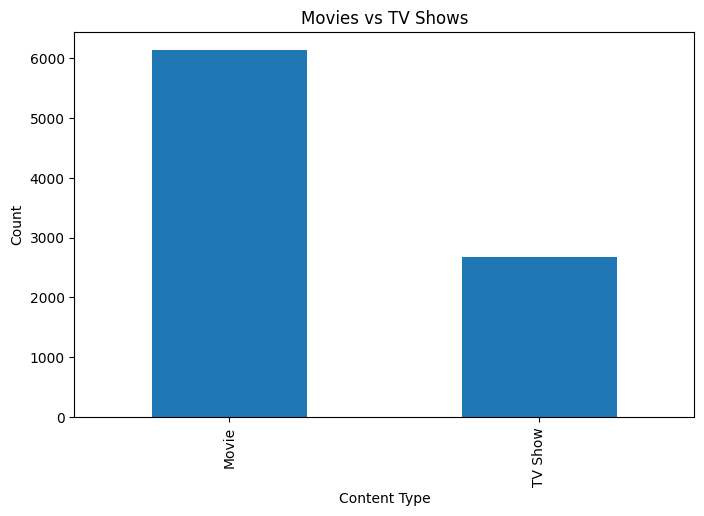

In [12]:
plt.figure(figsize=(8,5))

df_clean["type"].value_counts().plot(
    kind="bar"
)

plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

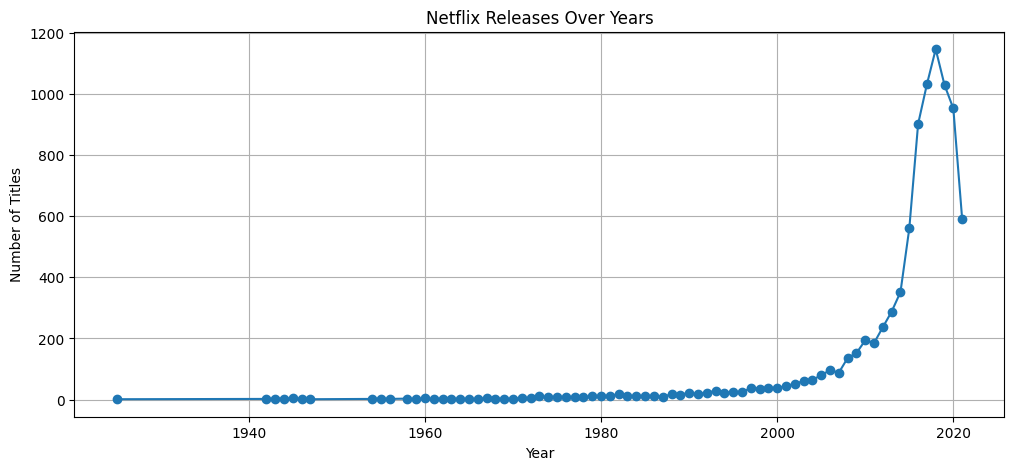

In [13]:
year_counts = (
    df_clean["release_year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,5))

plt.plot(
    year_counts.index,
    year_counts.values,
    marker="o"
)

plt.title("Netflix Releases Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid()

plt.show()

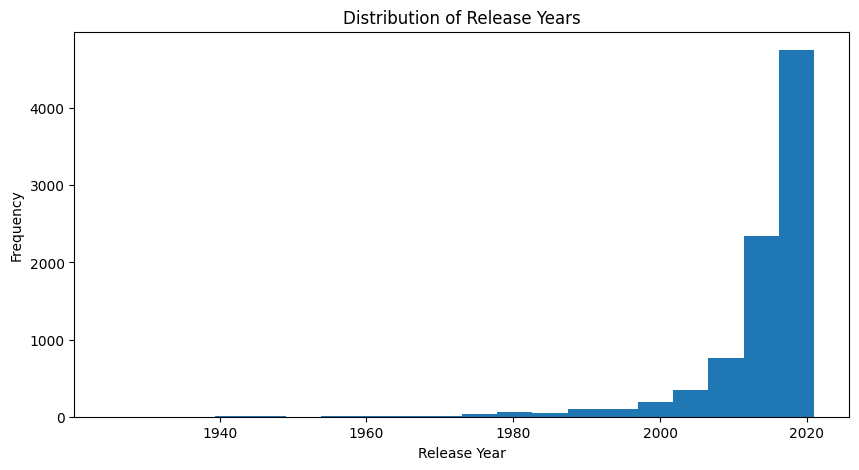

In [14]:
plt.figure(figsize=(10,5))

plt.hist(
    df_clean["release_year"],
    bins=20
)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Frequency")

plt.show()

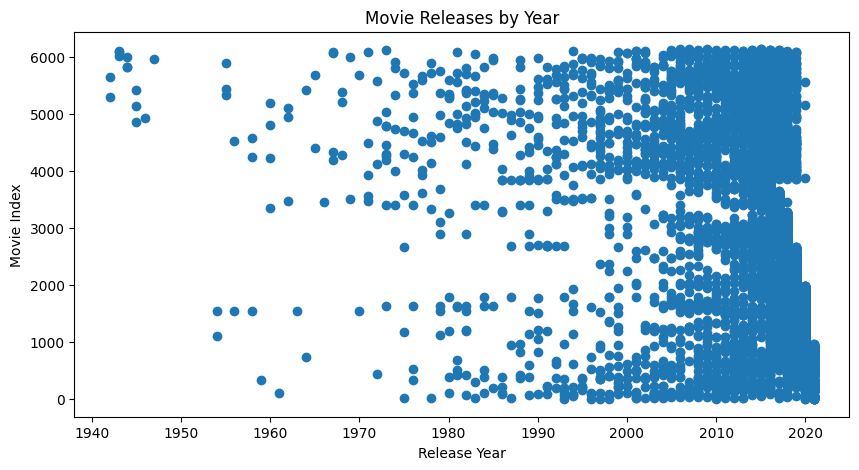

In [15]:
movie_data = df_clean[
    df_clean["type"] == "Movie"
]

plt.figure(figsize=(10,5))

plt.scatter(
    movie_data["release_year"],
    range(len(movie_data))
)

plt.title("Movie Releases by Year")
plt.xlabel("Release Year")
plt.ylabel("Movie Index")

plt.show()

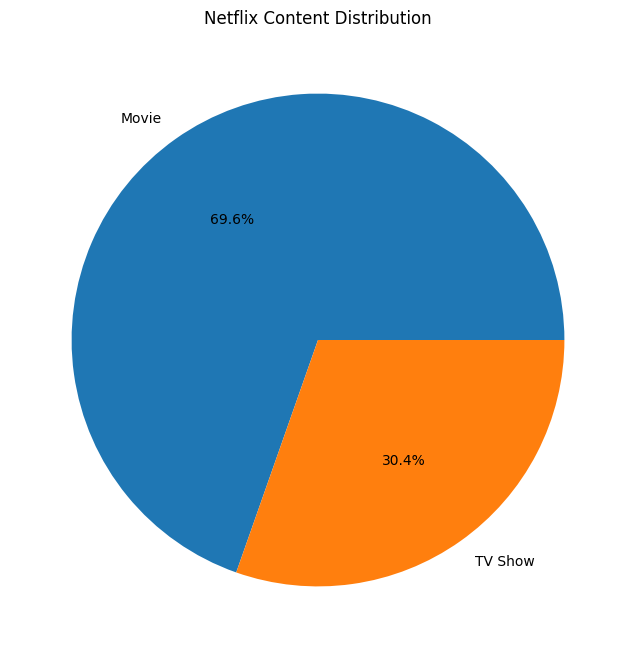

In [16]:
plt.figure(figsize=(8,8))

df_clean["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Netflix Content Distribution")

plt.ylabel("")

plt.show()

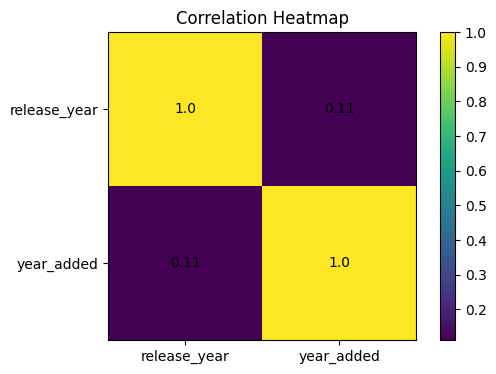

In [17]:
df_clean["year_added"] = (
    df_clean["date_added"]
    .dt.year
)

corr = df_clean[
    ["release_year", "year_added"]
].corr()

plt.figure(figsize=(6,4))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(
            j,
            i,
            round(corr.iloc[i, j], 2),
            ha="center",
            va="center"
        )

plt.title("Correlation Heatmap")

plt.show()

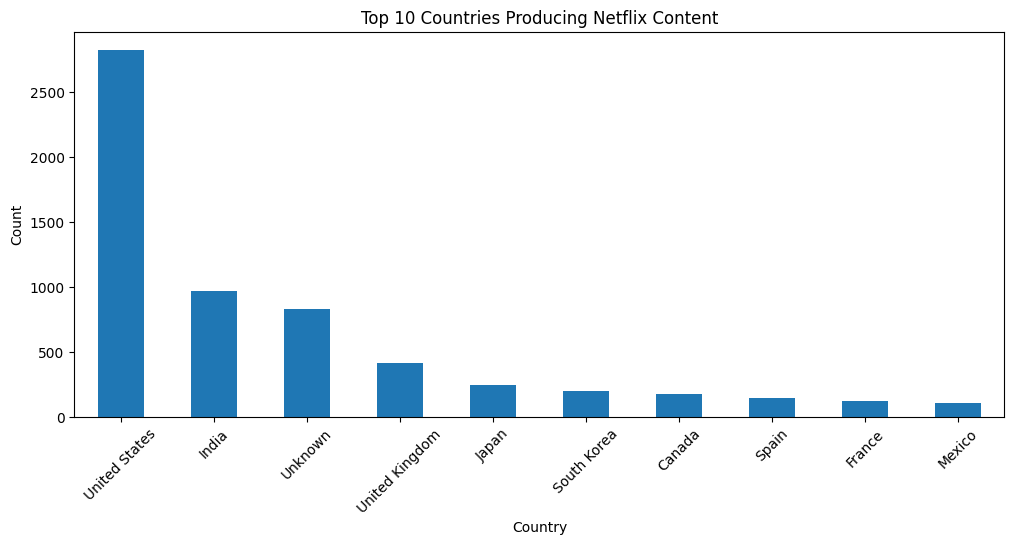

In [18]:
plt.figure(figsize=(12,5))

top_countries.plot(kind="bar")

plt.title(
    "Top 10 Countries Producing Netflix Content"
)

plt.xlabel("Country")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

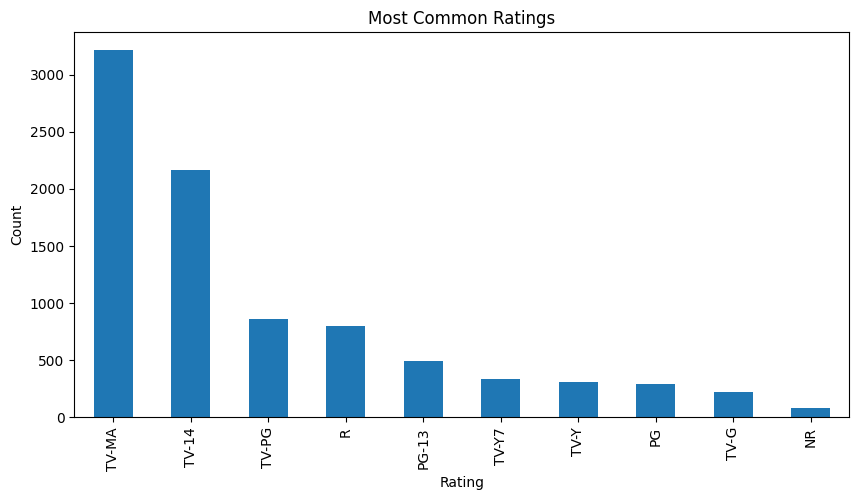

In [19]:
plt.figure(figsize=(10,5))

ratings.head(10).plot(
    kind="bar"
)

plt.title("Most Common Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [20]:
print("INSIGHT 1:")
print("Movies are more numerous than TV Shows on Netflix.")

print("\nINSIGHT 2:")
print("Netflix content increased significantly after 2015.")

print("\nINSIGHT 3:")
print("The United States contributes the highest amount of content.")

print("\nINSIGHT 4:")
print("TV-MA and TV-14 are the most common content ratings.")

print("\nINSIGHT 5:")
print("International Movies and Dramas are among the most popular genres.")

INSIGHT 1:
Movies are more numerous than TV Shows on Netflix.

INSIGHT 2:
Netflix content increased significantly after 2015.

INSIGHT 3:
The United States contributes the highest amount of content.

INSIGHT 4:
TV-MA and TV-14 are the most common content ratings.

INSIGHT 5:
International Movies and Dramas are among the most popular genres.


In [22]:
print("RECOMMENDATION 1:")
print("Increase investment in TV Shows.")

print("\nRECOMMENDATION 2:")
print("Expand content production in emerging countries.")

print("\nRECOMMENDATION 3:")
print("Focus on highly demanded genres.")

print("\nRECOMMENDATION 4:")
print("Continue producing content for mature audiences.")

print("\nRECOMMENDATION 5:")
print("Maintain strong yearly content growth.")

RECOMMENDATION 1:
Increase investment in TV Shows.

RECOMMENDATION 2:
Expand content production in emerging countries.

RECOMMENDATION 3:
Focus on highly demanded genres.

RECOMMENDATION 4:
Continue producing content for mature audiences.

RECOMMENDATION 5:
Maintain strong yearly content growth.
